In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [29]:


DATA_PATH = "/Users/lubhanamutha/Desktop/BMS/NASA/processed_soc"

csv_files = sorted([
    os.path.join(DATA_PATH, f)
    for f in os.listdir(DATA_PATH)
    if f.endswith(".csv")
])

print("Total cycles found:", len(csv_files))


Total cycles found: 341


In [30]:
cycles = []

for file in csv_files:
    df = pd.read_csv(file)

    # normalize mode column
    df['mode'] = df['mode'].astype(str).str.lower().str.strip()

    # keep discharge only
    df_dis = df[df['mode'] == 'discharge'].reset_index(drop=True)

    if len(df_dis) > 0:
        cycles.append(df_dis)

print("Valid discharge cycles:", len(cycles))


Valid discharge cycles: 171


By iterating through each cycle, it retains only the data points where the measured voltage is strictly above 2.7V, effectively slicing off the "tail end" of a discharge cycle where the voltage typically drops rapidly and becomes unstable. Using .reset_index(drop=True) ensures that each resulting DataFrame starts with a fresh index beginning at zero, removing the gaps from the deleted rows so that the time-series data remains clean and ready for further analysis or modeling.

In [31]:
V_CUTOFF = 2.7

for i in range(len(cycles)):
    cycles[i] = cycles[i][cycles[i]['Voltage_measured'] > V_CUTOFF].reset_index(drop=True)


In [33]:
for i in range(len(cycles)):
    cycles[i]['current'] = -cycles[i]['Current_measured']
    cycles[i]['voltage'] = cycles[i]['Voltage_measured']
    cycles[i]['time'] = cycles[i]['Time_uniform']


This code calculates the average sampling interval of your dataset to verify the consistency of your time steps. It extracts the time values from the first cycle, uses np.diff to calculate the gap between every consecutive timestamp, and then computes the mean of those gaps. By printing this dt value, you are confirming the temporal resolution of your data—which is a critical sanity check

In [34]:
time = cycles[0]['time'].values
dt = np.mean(np.diff(time))
print("Sampling time dt:", dt, "seconds")


Sampling time dt: 1.0191607284243864 seconds


The step method calculates the battery's state over one time interval: it updates the State of Charge (SoC) using Coulomb counting, solves the RC network dynamics using a discrete-time approximation to find the transient voltage drop V_{RC}, and finally calculates the terminal voltage (V_{ecm}) by subtracting the internal losses (Ohmic and RC) from the Open Circuit Voltage ($OCV$).

In [35]:
class BatteryECM:
    def __init__(self, Q, R0, R1, C1, dt, ocv_func, soc_init=1.0):
        self.Q = Q
        self.R0 = R0
        self.R1 = R1
        self.C1 = C1
        self.dt = dt
        self.ocv_func = ocv_func

        self.SOC = soc_init
        self.V_RC = 0.0

    def step(self, I):
        # SOC update
        self.SOC -= (I * self.dt) / (3600 * self.Q)
        self.SOC = np.clip(self.SOC, 0, 1)

        # RC dynamics
        alpha = np.exp(-self.dt / (self.R1 * self.C1))
        self.V_RC = alpha * self.V_RC + self.R1 * (1 - alpha) * I

        # Terminal voltage
        OCV = self.ocv_func(self.SOC)
        V_ecm = OCV - I * self.R0 - self.V_RC

        return self.SOC, self.V_RC, OCV, V_ecm


This code defines a linear approximation of the Open Circuit Voltage (OCV) as a function of the State of Charge (SoC). In battery modeling, the OCV represents the "resting" voltage of the cell when no current is flowing. This specific "dummy" function assumes a perfectly linear relationship where the battery voltage starts at 3.0V when completely empty ($SoC = 0$) and rises to 4.2V when fully charged ($SoC = 1$). While real lithium-ion batteries typically have a non-linear S-curve, this simplified linear model is often used as a placeholder to test the logic of an Equivalent Circuit Model (ECM) before implementing more complex look-up tables or high-order polynomials.

In [36]:
def ocv_dummy(soc):
    return 3.0 + 1.2 * soc


In [37]:
Q_rated = 2.3      # Ah
R0_init = 0.02     # Ohm (nominal)
R1_init = 0.01
C1_init = 2000


In [38]:
cycle = cycles[0]

ecm = BatteryECM(
    Q=Q_rated,
    R0=R0_init,
    R1=R1_init,
    C1=C1_init,
    dt=dt,
    ocv_func=ocv_dummy,
    soc_init=1.0
)

SOC, V_RC, OCV, V_ECM = [], [], [], []

for I in cycle['current'].values:
    s, vrc, ocv, vecm = ecm.step(I)
    SOC.append(s)
    V_RC.append(vrc)
    OCV.append(ocv)
    V_ECM.append(vecm)

cycle['SOC_ECM'] = SOC
cycle['V_RC'] = V_RC
cycle['OCV'] = OCV
cycle['V_ECM'] = V_ECM


In [39]:
soc = cycle['SOC_ECM'].values
voltage = cycle['voltage'].values

mask = (soc > 0.15) & (soc < 0.95)

soc_use = soc[mask]
voltage_use = voltage[mask]


In [40]:
bins = np.linspace(soc_use.min(), soc_use.max(), 50)

soc_bins, volt_bins = [], []

for i in range(len(bins)-1):
    idx = (soc_use >= bins[i]) & (soc_use < bins[i+1])
    if np.sum(idx) > 10:
        soc_bins.append(np.mean(soc_use[idx]))
        volt_bins.append(np.mean(voltage_use[idx]))

soc_bins = np.array(soc_bins)
volt_bins = np.array(volt_bins)


In [41]:
coeffs = np.polyfit(soc_bins, volt_bins, deg=5)
ocv_poly = np.poly1d(coeffs)

def ocv_fitted(soc):
    return ocv_poly(soc)


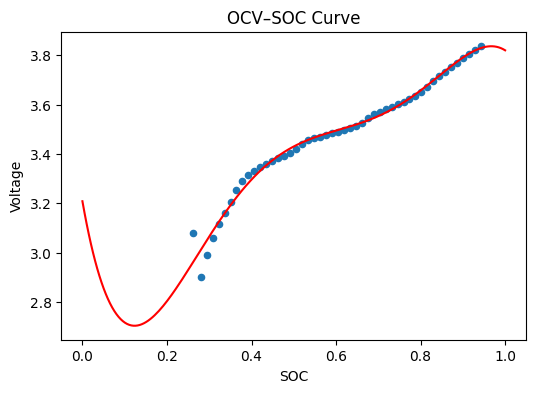

In [42]:
soc_grid = np.linspace(0, 1, 200)

plt.figure(figsize=(6,4))
plt.scatter(soc_bins, volt_bins, s=20)
plt.plot(soc_grid, ocv_fitted(soc_grid), 'r')
plt.xlabel("SOC")
plt.ylabel("Voltage")
plt.title("OCV–SOC Curve")
plt.show()


In [43]:
ecm = BatteryECM(
    Q=Q_rated,
    R0=R0_init,
    R1=R1_init,
    C1=C1_init,
    dt=dt,
    ocv_func=ocv_fitted,
    soc_init=1.0
)

SOC, V_RC, V_ECM = [], [], []

for I in cycle['current'].values:
    s, vrc, ocv, vecm = ecm.step(I)
    SOC.append(s)
    V_RC.append(vrc)
    V_ECM.append(vecm)

cycle['SOC_ECM'] = SOC
cycle['V_RC'] = V_RC
cycle['V_ECM'] = V_ECM
cycle['V_error'] = cycle['voltage'] - cycle['V_ECM']


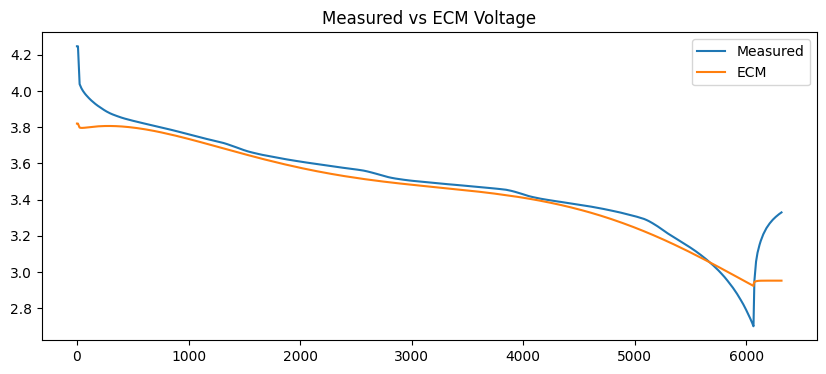

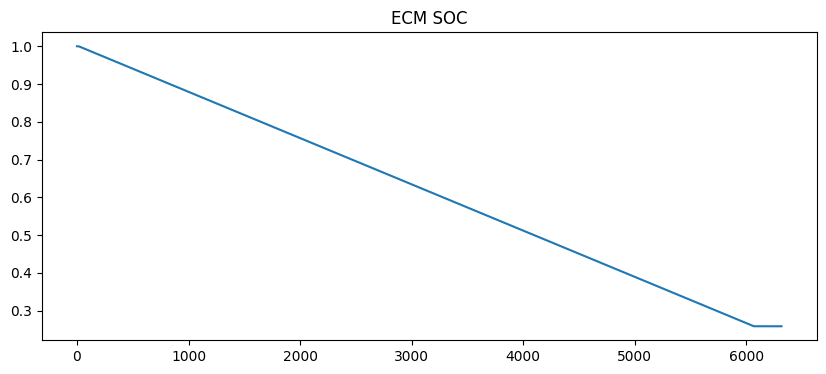

In [44]:
plt.figure(figsize=(10,4))
plt.plot(cycle['voltage'], label="Measured")
plt.plot(cycle['V_ECM'], label="ECM")
plt.legend()
plt.title("Measured vs ECM Voltage")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(cycle['SOC_ECM'])
plt.title("ECM SOC")
plt.show()


In [45]:
ecm_cycles = []   # list of ECM-enriched discharge cycles

for idx, cycle in enumerate(cycles):

    ecm = BatteryECM(
        Q=Q_rated,
        R0=R0_init,
        R1=R1_init,
        C1=C1_init,
        dt=dt,
        ocv_func=ocv_fitted,
        soc_init=1.0
    )

    SOC, V_RC, V_ECM = [], [], []

    for I in cycle['current'].values:
        s, vrc, ocv, vecm = ecm.step(I)
        SOC.append(s)
        V_RC.append(vrc)
        V_ECM.append(vecm)

    cycle_ecm = cycle.copy()
    cycle_ecm['SOC_ECM'] = SOC
    cycle_ecm['V_RC'] = V_RC
    cycle_ecm['V_ECM'] = V_ECM
    cycle_ecm['V_error'] = cycle_ecm['voltage'] - cycle_ecm['V_ECM']

    ecm_cycles.append(cycle_ecm)

print("ECM run on cycles:", len(ecm_cycles))


ECM run on cycles: 171


In [52]:
Q_used = []

for cycle in ecm_cycles:
    I = cycle['current'].values
    Q_cycle = np.sum(I * dt) / 3600  # Ah
    Q_used.append(Q_cycle)

Q_used = np.array(Q_used)

SOH_Q = Q_used / Q_used[0] # normalize
SOH_Q_smooth = np.convolve(SOH_Q, np.ones(5)/5, mode='same')

In [59]:
R_proxy = []

for cycle in ecm_cycles:
    I = np.abs(cycle['current'].values)
    V_err = np.abs(cycle['V_error'].values)

    mask = I > 0.3   # ignore low-current region

    if np.sum(mask) < 10:
        R_proxy.append(np.nan)
    else:
        R_proxy.append(np.median(V_err[mask] / I[mask]))

R_proxy = np.array(R_proxy)

# normalize
SOH_R = R_proxy[0] / R_proxy
SOH_R = np.clip(SOH_R, 0.2, 1.2)
SOH_R= np.convolve(SOH_R, np.ones(5)/5, mode='same')



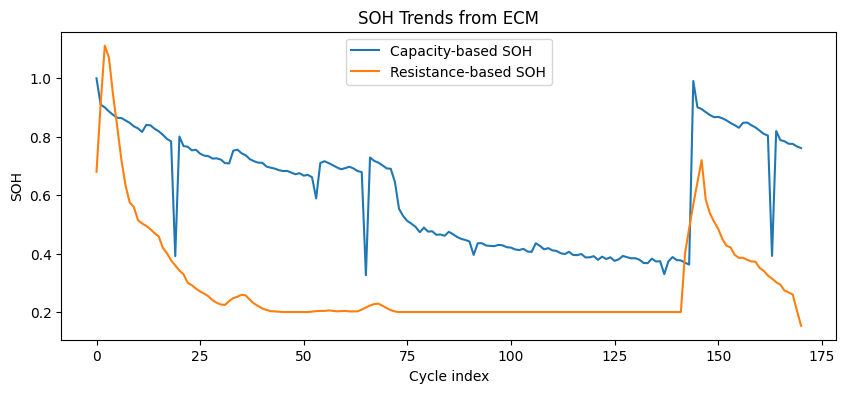

In [60]:
plt.figure(figsize=(10,4))
plt.plot(SOH_Q, label="Capacity-based SOH")
plt.plot(SOH_R, label="Resistance-based SOH")
plt.xlabel("Cycle index")
plt.ylabel("SOH")
plt.legend()
plt.title("SOH Trends from ECM")
plt.show()


In [61]:
full_cycles = []

for file in csv_files:
    df = pd.read_csv(file)
    df['mode'] = df['mode'].astype(str).str.lower().str.strip()
    full_cycles.append(df)


In [63]:
# initialize ECM columns
for col in ['SOC_ECM', 'V_RC', 'V_ECM']:
    df_full[col] = np.nan

# assign ONLY at indices where ECM exists
df_full.loc[df_ecm.index, ['SOC_ECM','V_RC','V_ECM']] = \
    df_ecm[['SOC_ECM','V_RC','V_ECM']].values

# carry forward through charge & low-voltage region
df_full[['SOC_ECM','V_RC','V_ECM']] = \
    df_full[['SOC_ECM','V_RC','V_ECM']].ffill()


In [71]:
valid_cycle_indices = []  # indices into full_cycles

for i, file in enumerate(csv_files):
    df = pd.read_csv(file)
    df['mode'] = df['mode'].str.lower().str.strip()

    df_dis = df[df['mode'] == 'discharge']
    if len(df_dis) > 0:
        valid_cycle_indices.append(i)
        cycles.append(df_dis)


In [72]:
ecm_cycle_map = dict(zip(valid_cycle_indices, ecm_cycles))


In [73]:
merged_cycles = []

for i, df_full in enumerate(full_cycles):

    df_full = df_full.copy()

    # Remove old ECM columns if present
    for col in ['SOC_ECM', 'V_RC', 'V_ECM']:
        if col in df_full.columns:
            df_full.drop(columns=col, inplace=True)

    # Case 1: this cycle HAS ECM
    if i in ecm_cycle_map:
        df_ecm = ecm_cycle_map[i]

        df_ecm_small = df_ecm[['Time_uniform', 'SOC_ECM', 'V_RC', 'V_ECM']].copy()

        df_full = df_full.merge(
            df_ecm_small,
            on='Time_uniform',
            how='left'
        )

        # carry forward ECM states
        df_full[['SOC_ECM', 'V_RC', 'V_ECM']] = (
            df_full[['SOC_ECM', 'V_RC', 'V_ECM']].ffill()
        )

    # Case 2: this cycle has NO ECM
    else:
        df_full['SOC_ECM'] = np.nan
        df_full['V_RC'] = np.nan
        df_full['V_ECM'] = np.nan

    # mode flag always exists
    df_full['mode_flag'] = (df_full['mode'] == 'discharge').astype(int)

    merged_cycles.append(df_full)


In [74]:
print(len(full_cycles))
print(len(ecm_cycles))
print(len(merged_cycles))

print(sum(c['SOC_ECM'].notna().any() for c in merged_cycles))


341
171
341
171


In [75]:
SAVE_DIR = "ECM_processed_cycles"
os.makedirs(SAVE_DIR, exist_ok=True)

for i, df in enumerate(merged_cycles):
    df.to_csv(f"{SAVE_DIR}/cycle_{i:04d}.csv", index=False)
